In [1]:
import omicverse as ov
ov.plot_set()

2024-11-21 19:41:57.633807: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-21 19:41:57.655641: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-21 19:41:57.662196: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-21 19:41:58.718812: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT



   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.9, Tutorials: https://omicverse.readthedocs.io/
Dependency error: (pydeseq2 0.4.11 (/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages), Requirement.parse('pydeseq2<=0.4.0,>=0.3'))


In [2]:
import scanpy as sc
ref_adata = sc.read('data/GC_RNA/GC_All_ANNO.h5ad')
ref_adata = ref_adata[:,ref_adata.var_names]
print(ref_adata)
#print(ref_adata.obs.Celltype.value_counts())

View of AnnData object with n_obs × n_vars = 150222 × 15496
    obs: 'patient', 'CancerType', 'CancerStage', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'n_genes', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', '_scvi_batch', '_scvi_labels', 'leiden', 'celltype_gbi', 'celltype_gpt', 'best_clusters', 'gpt_celltype_0', 'gpt_celltype_1', 'gpt_celltype_2', 'gpt_celltype_3', 'gpt_celltype_4', 'best_celltype', 'Major_celltype', 'Minor_celltype', 'C_scANVI', 'cell_type_from_scMulan', 'cell_type_from_mulan_smoothing', 'smoothing_score'
    var: 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_features'
    uns: 'CancerStage_colors', 'CancerType_colors', 'Smoothing', 'bench_best_res', 'best_celltype_colors', 'cell_type_from_mulan_smoothing_colors', 'cell_type_from_scMulan_colors', 'dendrogram_leiden', '

In [3]:
ref_adata

View of AnnData object with n_obs × n_vars = 150222 × 15496
    obs: 'patient', 'CancerType', 'CancerStage', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'n_genes', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', '_scvi_batch', '_scvi_labels', 'leiden', 'celltype_gbi', 'celltype_gpt', 'best_clusters', 'gpt_celltype_0', 'gpt_celltype_1', 'gpt_celltype_2', 'gpt_celltype_3', 'gpt_celltype_4', 'best_celltype', 'Major_celltype', 'Minor_celltype', 'C_scANVI', 'cell_type_from_scMulan', 'cell_type_from_mulan_smoothing', 'smoothing_score'
    var: 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_features'
    uns: 'CancerStage_colors', 'CancerType_colors', 'Smoothing', 'bench_best_res', 'best_celltype_colors', 'cell_type_from_mulan_smoothing_colors', 'cell_type_from_scMulan_colors', 'dendrogram_leiden', '

In [4]:
import random
from tqdm import tqdm
cell_ids=[]
for ct in tqdm(ref_adata.obs['best_celltype'].unique()):
    if ref_adata[ref_adata.obs['best_celltype']==ct].shape[0]>1000:
        cell_idx=random.sample(ref_adata[ref_adata.obs['best_celltype']==ct].obs.index.tolist(),1000)
    else:
        cell_idx=ref_adata[ref_adata.obs['best_celltype']==ct].obs.index.tolist()
    cell_ids+=cell_idx

100%|██████████| 23/23 [00:00<00:00, 37.72it/s]


In [5]:
ref_adata=ref_adata[cell_ids]
ref_adata

View of AnnData object with n_obs × n_vars = 19641 × 15496
    obs: 'patient', 'CancerType', 'CancerStage', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'n_genes', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', '_scvi_batch', '_scvi_labels', 'leiden', 'celltype_gbi', 'celltype_gpt', 'best_clusters', 'gpt_celltype_0', 'gpt_celltype_1', 'gpt_celltype_2', 'gpt_celltype_3', 'gpt_celltype_4', 'best_celltype', 'Major_celltype', 'Minor_celltype', 'C_scANVI', 'cell_type_from_scMulan', 'cell_type_from_mulan_smoothing', 'smoothing_score'
    var: 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_features'
    uns: 'CancerStage_colors', 'CancerType_colors', 'Smoothing', 'bench_best_res', 'best_celltype_colors', 'cell_type_from_mulan_smoothing_colors', 'cell_type_from_scMulan_colors', 'dendrogram_leiden', 'h

In [6]:
ref_adata=ov.pp.preprocess(ref_adata,mode='shiftlog|pearson',n_HVGs=2000,)

Begin robust gene identification
After filtration, 15496/15496 genes are kept.     Among 15496 genes, 15482 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['GKN1', 'GHRL', 'SST', 'MLN', 'PGC', 'DEFA5', 'SPINK4', 'LIPF', 'HBB', 'PGA3', 'PGA5', 'FTH1', 'MALAT1', 'APOA1', 'LYZ', 'NTS', 'CHGA', 'CRIP1', 'MT1G', 'GAST', 'GIP', 'FTL', 'TFF2', 'TFF1', 'IGLL5']
    finished (0:00:00)
extracting highly variable genes
--> added
    'highly_variable', boolean vector (adata.var)
    'highly_variable_rank', float vector (adata.var)
    'highly_variable_nbatches', int vector (adata.var)
    'highly_variable_intersection', boolean vector (adata.var)
    'means', float vector (adata.var)
    'variances', float vector (adata.var)
    'residual_variances', float vector (adata.var)
Time to analyze data in cpu: 17.

In [7]:
ref_adata.raw=ref_adata
ref_adata=ref_adata[:,ref_adata.var.highly_variable_features]
ref_adata

View of AnnData object with n_obs × n_vars = 19641 × 2000
    obs: 'patient', 'CancerType', 'CancerStage', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'n_genes', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', '_scvi_batch', '_scvi_labels', 'leiden', 'celltype_gbi', 'celltype_gpt', 'best_clusters', 'gpt_celltype_0', 'gpt_celltype_1', 'gpt_celltype_2', 'gpt_celltype_3', 'gpt_celltype_4', 'best_celltype', 'Major_celltype', 'Minor_celltype', 'C_scANVI', 'cell_type_from_scMulan', 'cell_type_from_mulan_smoothing', 'smoothing_score'
    var: 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_features'
    uns: 'CancerStage_colors', 'CancerType_colors', 'Smoothing', 'bench_best_res', 'best_celltype_colors', 'cell_type_from_mulan_smoothing_colors', 'cell_type_from_scMulan_colors', 'dendrogram_leiden', 'hv

In [8]:
ref_adata.write('data/GC_RNA/GC_REF.h5ad',compression='gzip')

In [2]:
ref_adata=ov.read('data/GC_RNA/GC_REF.h5ad')
ref_adata

AnnData object with n_obs × n_vars = 19641 × 2000
    obs: 'patient', 'CancerType', 'CancerStage', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'n_genes', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', '_scvi_batch', '_scvi_labels', 'leiden', 'celltype_gbi', 'celltype_gpt', 'best_clusters', 'gpt_celltype_0', 'gpt_celltype_1', 'gpt_celltype_2', 'gpt_celltype_3', 'gpt_celltype_4', 'best_celltype', 'Major_celltype', 'Minor_celltype', 'C_scANVI', 'cell_type_from_scMulan', 'cell_type_from_mulan_smoothing', 'smoothing_score'
    var: 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_features'
    uns: 'CancerStage_colors', 'CancerType_colors', 'Smoothing', 'bench_best_res', 'best_celltype_colors', 'cell_type_from_mulan_smoothing_colors', 'cell_type_from_scMulan_colors', 'dendrogram_leiden', 'hvg', 'lei

In [30]:
dataset_id='Run5458_0507'
query_adata = ov.read(f'data/{dataset_id}_cast_result.h5ad')
query_adata = query_adata[:,query_adata.var_names]
print(query_adata)
#print(query_adata.obs.Celltype.value_counts())

View of AnnData object with n_obs × n_vars = 137024 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'fov_labels', 'cell_ID', 'x', 'y', 'cast_clusters'
    uns: 'fov_labels_colors', 'spatialdata_attrs'
    obsm: 'X_cast', 'global', 'spatial'
    layers: 'norm_1e4'


In [ ]:
query_adata=ov.pp.preprocess(query_adata,mode='shiftlog|pearson',n_HVGs=2000,)


In [15]:
adata_GS_uniformed = ov.externel.scMulan.GeneSymbolUniform(input_adata=query_adata,
                                                               output_dir='result',
                                                               output_prefix='GC_cosmx')

{message}
The shape of query data is: (137024, 979)
The length of reference gene_list is: 42117
Performing gene symbol uniform, this step may take several minutes


Processing: 100%|██████████| 979/979 [00:00<00:00, 1125.26it/s]


Building output data, this step may take several minutes


Processing: 100%|██████████| 960/960 [00:02<00:00, 406.28it/s]


Because the number of cells is very large, we construct the sparse matrix parallelly with 10 threads


Building matrices: 100%|██████████| 10/10 [00:03<00:00,  2.63it/s]


Shape of output data is (137024, 42117). It should have 42117 genes with cell number unchanged.
h5ad file saved in:/mnt/home/zehuazeng/analysis/24_GC/result/GC_cosmx_uniformed.h5ad
report file saved in: /mnt/home/zehuazeng/analysis/24_GC/result/GC_cosmx_report.csv


In [16]:
adata_GS_uniformed

AnnData object with n_obs × n_vars = 137024 × 42117
    obs: 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'fov_labels', 'cell_ID', 'x', 'y', 'cast_clusters'

In [17]:
#ref_adata.var_names_make_unique()
#query_adata.var_names_make_unique()
ret_gene=list(set(adata_GS_uniformed.var_names) & set(ref_adata.var_names))
len(ret_gene)

2000

In [19]:
query_adata=adata_GS_uniformed[:,ret_gene]
ref_adata=ref_adata[:,ret_gene]

In [21]:
query_adata

View of AnnData object with n_obs × n_vars = 137024 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'fov_labels', 'cell_ID', 'x', 'y', 'cast_clusters'

In [22]:
ref_adata

View of AnnData object with n_obs × n_vars = 19641 × 2000
    obs: 'patient', 'CancerType', 'CancerStage', 'nUMIs', 'mito_perc', 'detected_genes', 'cell_complexity', 'n_genes', 'doublet_score', 'predicted_doublet', 'passing_mt', 'passing_nUMIs', 'passing_ngenes', '_scvi_batch', '_scvi_labels', 'leiden', 'celltype_gbi', 'celltype_gpt', 'best_clusters', 'gpt_celltype_0', 'gpt_celltype_1', 'gpt_celltype_2', 'gpt_celltype_3', 'gpt_celltype_4', 'best_celltype', 'Major_celltype', 'Minor_celltype', 'C_scANVI', 'cell_type_from_scMulan', 'cell_type_from_mulan_smoothing', 'smoothing_score'
    var: 'mt', 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_nbatches', 'highly_variable_intersection', 'highly_variable_features'
    uns: 'CancerStage_colors', 'CancerType_colors', 'Smoothing', 'bench_best_res', 'best_celltype_colors', 'cell_type_from_mulan_smoothing_colors', 'cell_type_from_scMulan_colors', 'dendrogram_leiden', 'hv

In [20]:
print(f"The max of ref_adata is {ref_adata.X.max()}, query_data is {query_adata.X.max()}",)

The max of ref_adata is 15.134171372232387, query_data is 16.61887099947687


In [23]:
tosica_obj=ov.single.pyTOSICA(adata=ref_adata,
                              gmt_path='genesets/GO_bp.gmt', depth=1,
                              label_name='best_celltype',
                              project_path='hGOBP_demo',
                              batch_size=8)

cuda:0
Mask loaded!


In [25]:
tosica_obj.train(epochs=10)
tosica_obj.save()

Model builded!


[valid epoch 9] loss: 0.285, acc: 0.914: 100%|██████████| 862/862 [00:03<00:00, 275.27it/s]


Training finished!
Model saved!


In [26]:
new_adata=tosica_obj.predicted(pre_adata=query_adata)


0
10000
20000
30000
40000
50000
60000
70000
80000
90000
100000
110000
120000
130000
137024


AnnData object with n_obs × n_vars = 137024 × 299
    obs: 'Prediction', 'Probability', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'fov_labels', 'cell_ID', 'x', 'y', 'cast_clusters'

In [31]:
new_adata.obsm=query_adata[new_adata.obs.index].obsm.copy()
new_adata.obsp=query_adata[new_adata.obs.index].obsp.copy()
new_adata

AnnData object with n_obs × n_vars = 137024 × 299
    obs: 'Prediction', 'Probability', 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'fov_labels', 'cell_ID', 'x', 'y', 'cast_clusters'
    obsm: 'X_cast', 'global', 'spatial'

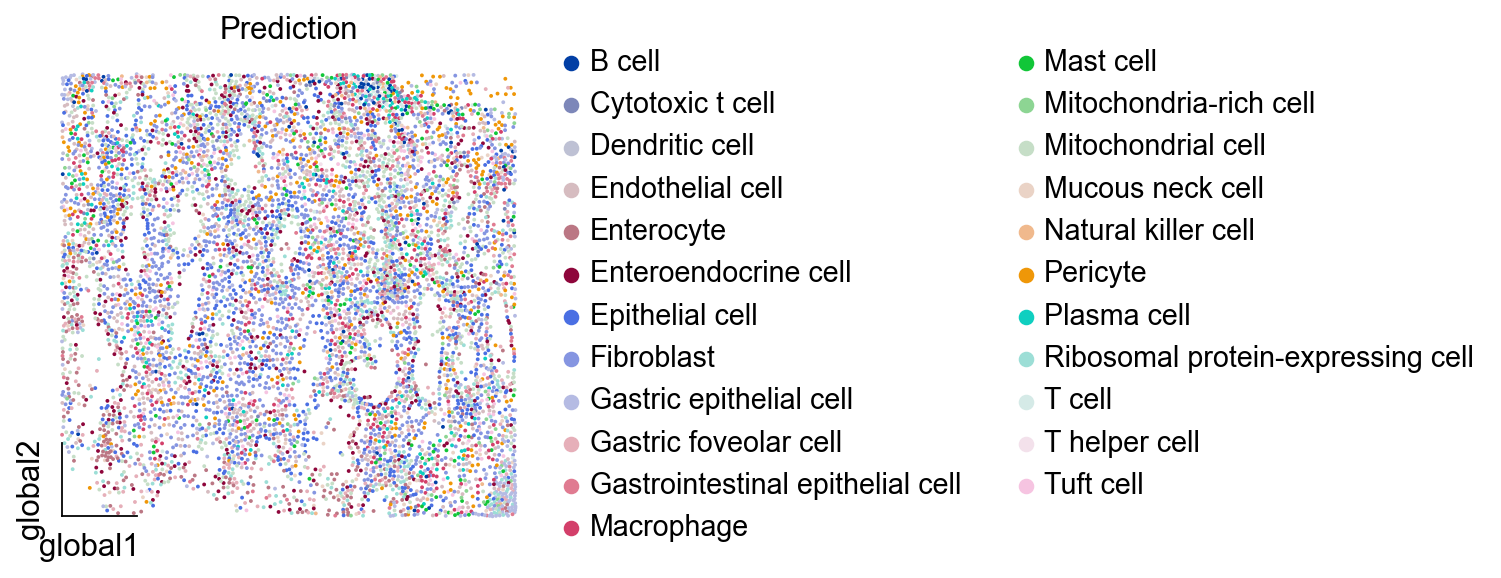

In [32]:
adata_test=new_adata[new_adata.obs['fov_labels']=='2_labels']
import matplotlib.pyplot as plt
#fig,ax=plt.subplots(figsize = (8,8))
ov.pl.embedding(adata_test,basis='global',
                color=['Prediction'],
                frameon='small',size=12,ncols=1)

In [36]:
query_adata.obs['Prediction']=new_adata[query_adata.obs.index].obs['Prediction'].tolist()
query_adata.obs['Probability']=new_adata[query_adata.obs.index].obs['Probability'].tolist()

In [46]:
query_adata

AnnData object with n_obs × n_vars = 137024 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'fov_labels', 'cell_ID', 'x', 'y', 'cast_clusters', 'Prediction', 'Probability'
    uns: 'fov_labels_colors', 'spatialdata_attrs'
    obsm: 'X_cast', 'global', 'spatial'
    layers: 'norm_1e4'

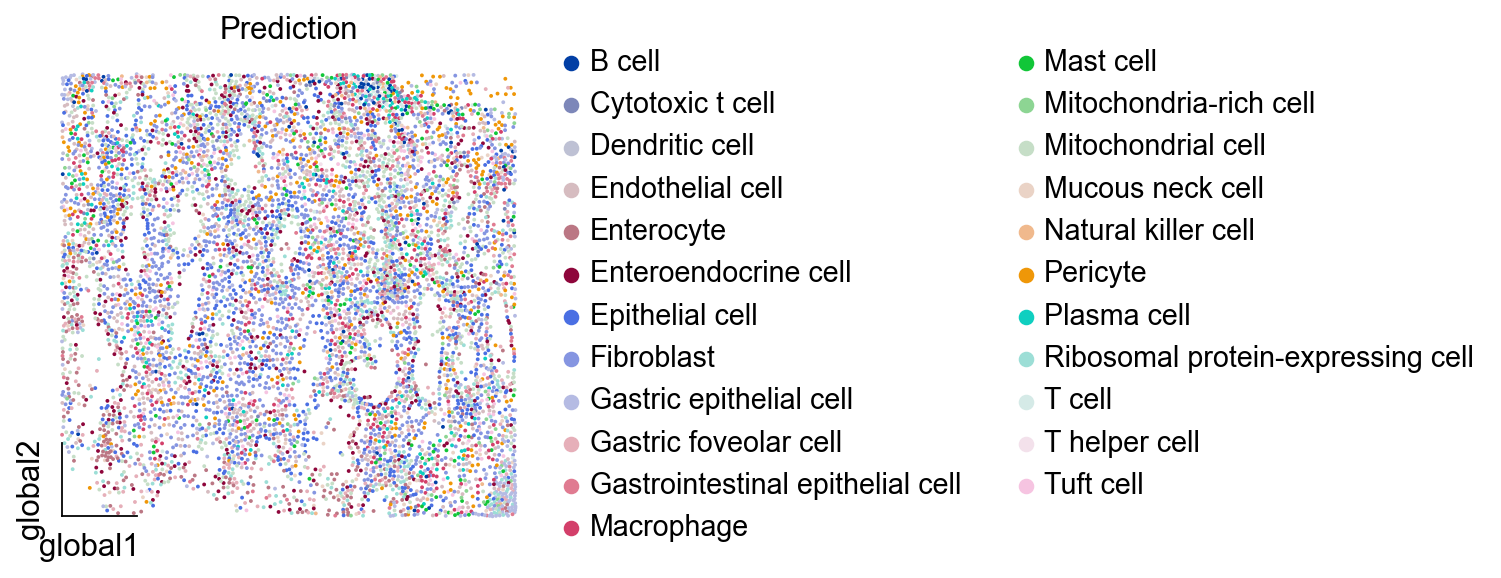

In [37]:
adata_test=query_adata[query_adata.obs['fov_labels']=='2_labels']
import matplotlib.pyplot as plt
#fig,ax=plt.subplots(figsize = (8,8))
ov.pl.embedding(adata_test,basis='global',
                color=['Prediction'],
                frameon='small',size=12,ncols=1)

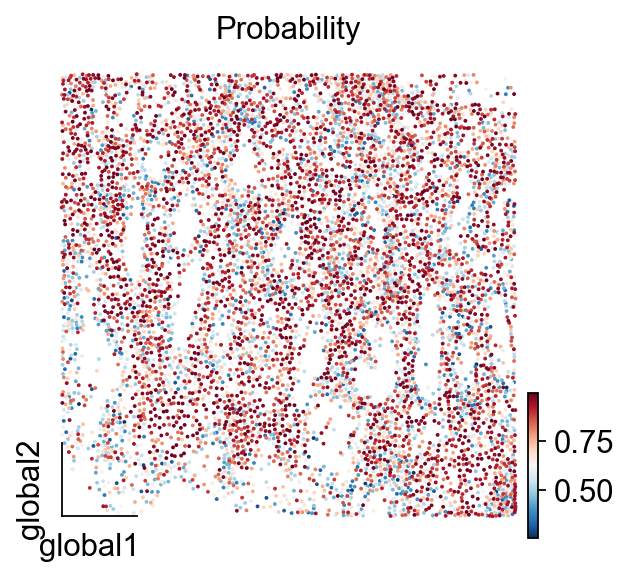

In [42]:
ov.pl.embedding(adata_test,basis='global',
                color=['Probability'],
                frameon='small',size=12,ncols=1)

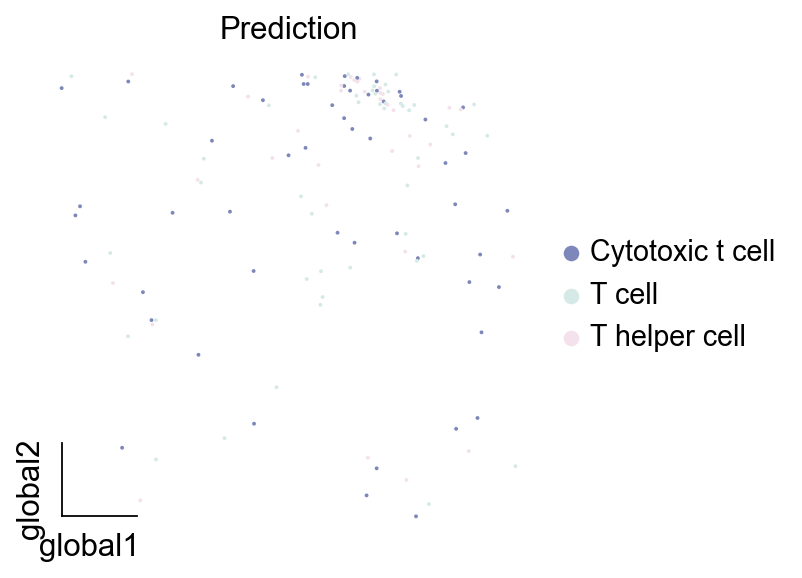

In [40]:
ov.pl.embedding(adata_test[adata_test.obs['Prediction'].isin([
    'T cell','T helper cell','Cytotoxic t cell'
])],basis='global',
                color=['Prediction'],
                frameon='small',size=12,ncols=1)

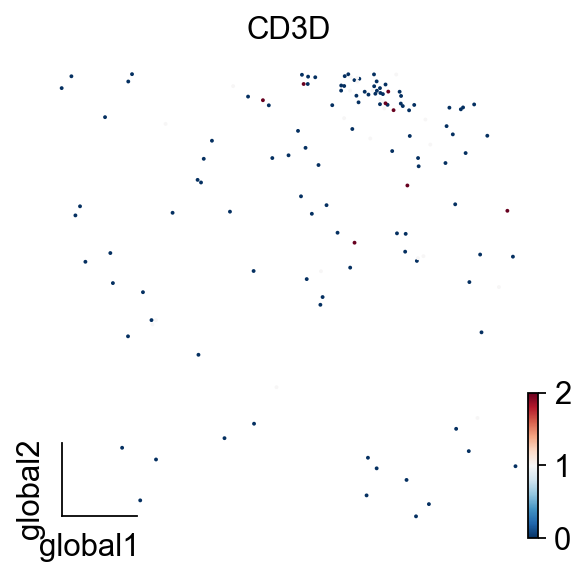

In [41]:
ov.pl.embedding(adata_test[adata_test.obs['Prediction'].isin([
    'T cell','T helper cell','Cytotoxic t cell'
])],basis='global',
                color=['CD3D'],
                frameon='small',size=12,ncols=1)

In [47]:
query_adata.write(f'data/{dataset_id}_tosica_anno.h5ad')

In [48]:
query_adata

AnnData object with n_obs × n_vars = 137024 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'fov_labels', 'cell_ID', 'x', 'y', 'cast_clusters', 'Prediction', 'Probability'
    uns: 'fov_labels_colors', 'spatialdata_attrs'
    obsm: 'X_cast', 'global', 'spatial'
    layers: 'norm_1e4'

In [49]:
%%time
query_adata=ov.pp.preprocess(query_adata,mode='shiftlog|pearson',n_HVGs=2000,)
ov.single.batch_correction(query_adata,batch_key='fov_labels',
                           methods='scVI',n_layers=2, n_latent=30, gene_likelihood="nb")
query_adata

Begin robust gene identification
After filtration, 979/979 genes are kept.     Among 979 genes, 979 genes are robust.
End of robust gene identification.
Begin size normalization: shiftlog and HVGs selection pearson
normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['AATK', 'ABL1', 'ABL2', 'ACE2', 'ACKR1', 'ACKR3', 'ACKR4', 'ACTA2', 'ACTG2', 'ACVR1', 'ACVR1B', 'ACVR2A', 'ADGRA2', 'ADGRA3', 'ADGRB3', 'ADGRE2', 'ADGRF1', 'ADGRF3', 'ADGRF4', 'ADGRF5', 'ADGRG1', 'ADGRG3', 'ADGRG5', 'ADGRG6', 'ADGRL1', 'ADGRL2', 'ADGRV1', 'ADIPOQ', 'ADIRF', 'ADORA2A', 'AGR2', 'AHI1', 'AHR', 'AKT1', 'ANGPT2', 'ANGPT4', 'ANGPTL1', 'ANXA1', 'ANXA2', 'ANXA4', 'APOA1', 'APOB', 'APOD', 'APP', 'AR', 'ARF1', 'ARHGDIB', 'ARTN', 'ATF3', 'ATG10', 'ATG12', 'ATG5', 'ATR', 'AXL', 'AZGP1', 'AZU1', 'B2M', 'B3GNT7', 'BAG3', 'BAX', 'BCL2', 'BCL2L1', 'BECN1', 'BIRC5', 'BMP1', 'BMP2', 'BMP3', 'BMP4', 'BMP5', 'BTG1', 'C11orf96', 'C1QA', 'C1QB', 'C1QC', '

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 58/58: 100%|██████████| 58/58 [08:37<00:00,  9.11s/it, v_num=1, train_loss_step=256, train_loss_epoch=265]

`Trainer.fit` stopped: `max_epochs=58` reached.


Epoch 58/58: 100%|██████████| 58/58 [08:37<00:00,  8.91s/it, v_num=1, train_loss_step=256, train_loss_epoch=265]
CPU times: user 8min 52s, sys: 2.94 s, total: 8min 55s
Wall time: 8min 48s


AnnData object with n_obs × n_vars = 137024 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'fov_labels', 'cell_ID', 'x', 'y', 'cast_clusters', 'Prediction', 'Probability', '_scvi_batch', '_scvi_labels'
    var: 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'fov_labels_colors', 'spatialdata_attrs', 'log1p', 'hvg', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_cast', 'global', 'spatial', 'X_scVI'
    layers: 'norm_1e4', 'counts'

Nov 21 08:09:57 PM: Your dataset appears to contain duplicated items (rows); when embedding, you should typically have unique items.
Nov 21 08:09:57 PM: The following items have duplicates [  5679   6673   9857  10062  11904  14514  20632  20908  25466  26315
  26619  26863  27203  27573  27635  31078  31397  31952  33027  33473
  33548  34066  38011  38373  38615  40765  43602  43728  44031  48441
  54869  55192  60456  61172  68095  74713  74784  74810  75115  80181
  80188  93080  93247  96846  97581  99456 102296 103393 106189 106359
 106482 108670 109180 109183 113981 115142 115693 119055 119225 119265
 119718 119837 119854 119861 123539 125187 125714 126711 131000 133969
 133970 133971 134664 134853 136007 136642 136710]


[<AxesSubplot: title={'center': 'fov_labels'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>,
 <AxesSubplot: title={'center': 'Prediction'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>]

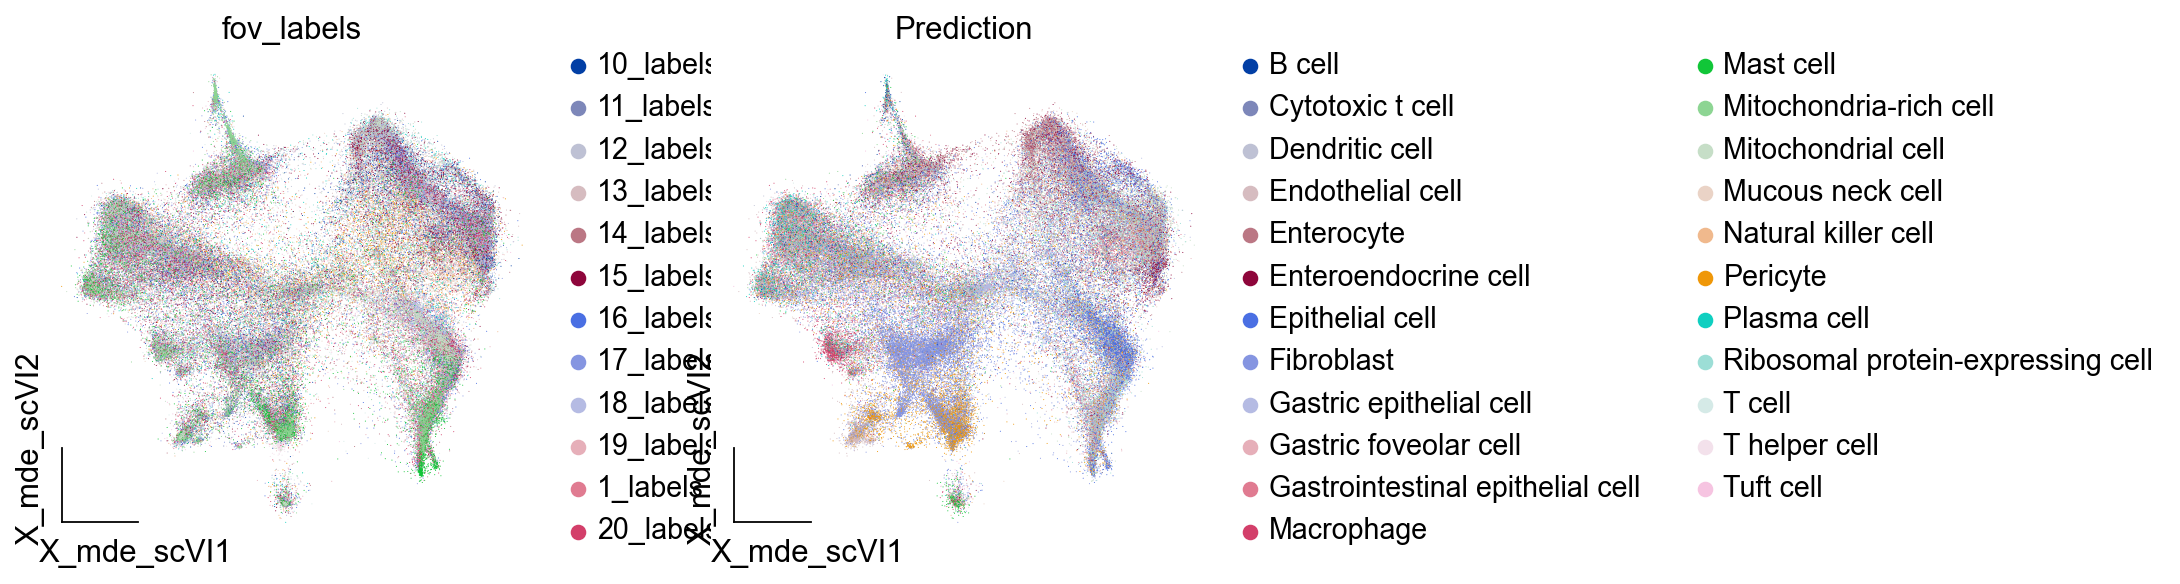

In [50]:
query_adata.obsm["X_mde_scVI"] = ov.utils.mde(query_adata.obsm["X_scVI"])
ov.utils.embedding(query_adata,
                basis='X_mde_scVI',frameon='small',
                color=['fov_labels','Prediction'],show=False)

<AxesSubplot: title={'center': 'MS4A1'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>

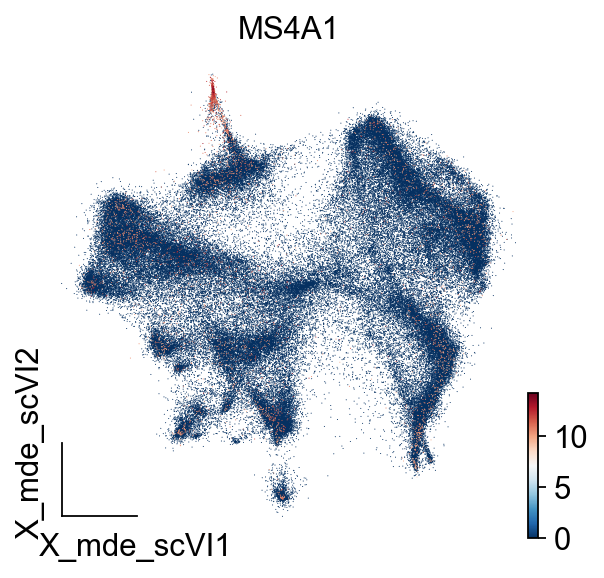

In [72]:
ov.utils.embedding(query_adata,
                basis='X_mde_scVI',frameon='small',
                color=['MS4A1'],show=False)

In [57]:
ov.externel.scMulan.cell_type_smoothing?

Signature:
ov.externel.scMulan.cell_type_smoothing(
    adata,
    use_rep='X_pca',
    N_neighbors=15,
    n_pcs=10,
    weighted_smoothing=True,
    threshold=0.5,
    col_name='cell_type_from_scMulan',
)
Docstring: <no docstring>
File:      ~/software/rsc/lib/python3.10/site-packages/omicverse/externel/scMulan/utils/utils.py
Type:      function

In [59]:
query_adata.write(f'data/{dataset_id}_tosica_anno.h5ad')

In [60]:
ov.externel.scMulan.cell_type_smoothing(query_adata, use_rep='X_scVI',
                                        col_name='Prediction',
                                        threshold=0.1)
query_adata

computing neighbors
    finished: added to `.uns['Smoothing']`
    `.obsp['Smoothing_distances']`, distances for each pair of neighbors
    `.obsp['Smoothing_connectivities']`, weighted adjacency matrix (0:00:31)


100%|██████████| 137024/137024 [04:19<00:00, 527.81it/s]


AnnData object with n_obs × n_vars = 137024 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD45', 'Max.CD45', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'fov_labels', 'cell_ID', 'x', 'y', 'cast_clusters', 'Prediction', 'Probability', '_scvi_batch', '_scvi_labels', 'cell_type_from_mulan_smoothing', 'smoothing_score'
    var: 'n_cells', 'percent_cells', 'robust', 'means', 'variances', 'residual_variances', 'highly_variable_rank', 'highly_variable_features'
    uns: 'fov_labels_colors', 'spatialdata_attrs', 'log1p', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'Prediction_colors', 'Smoothing', 'cell_type_from_mulan_smoothing_colors'
    obsm: 'X_cast', 'global', 'spatial', 'X_scVI', 'X_mde_scVI'
    layers: 'norm_1e4', 'counts'
    obsp: 'Smoothing_distances', 'Smoothing_connectivities'

<AxesSubplot: title={'center': 'cell_type_from_mulan_smoothing'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>

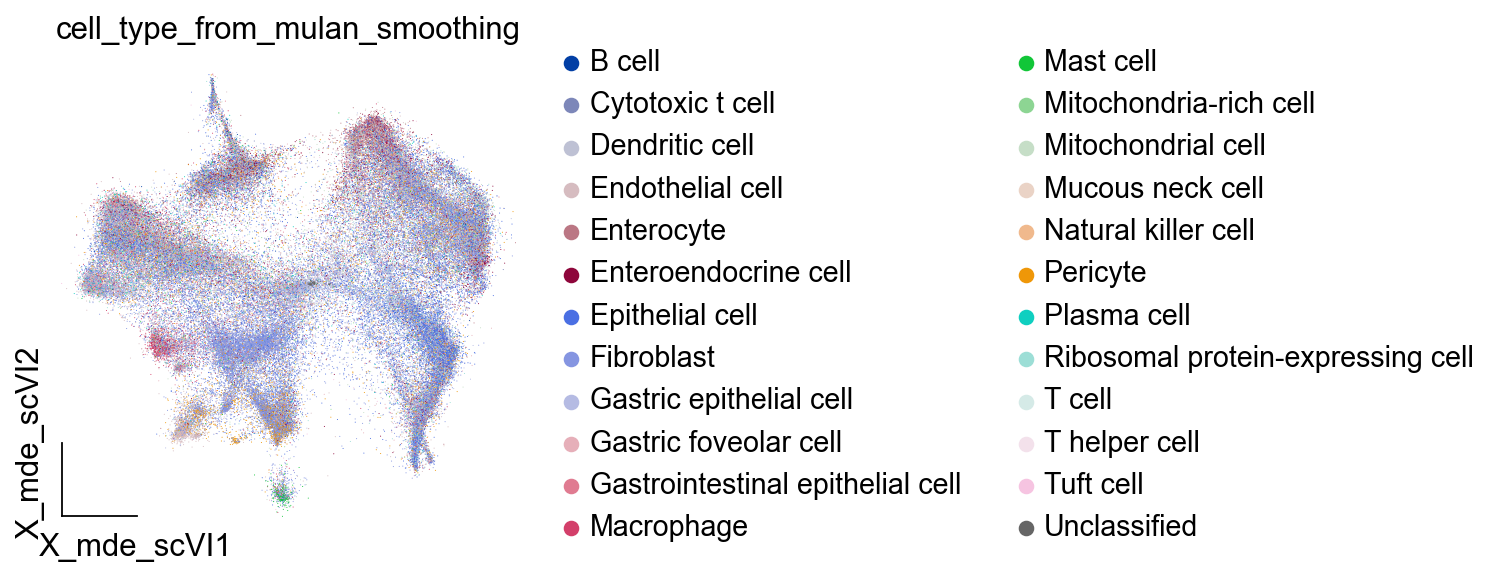

In [61]:
ov.utils.embedding(query_adata,
                basis='X_mde_scVI',frameon='small',
                color=['cell_type_from_mulan_smoothing'],show=False)

In [ ]:
%%time
ov.pp.neighbors(query_adata, n_neighbors=15, n_pcs=30,
               use_rep='X_scVI')


In [76]:
ov.pp.leiden(query_adata,resolution=2)

running Leiden clustering
    finished: found 26 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:02:18)


<AxesSubplot: title={'center': 'leiden'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>

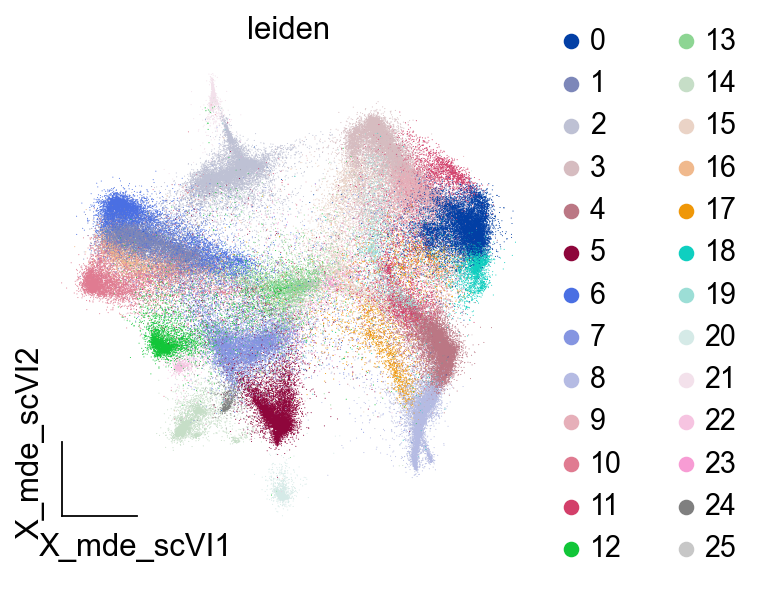

In [77]:
ov.utils.embedding(query_adata,
                basis='X_mde_scVI',frameon='small',
                color=['leiden'],show=False)

Storing dendrogram info using `.uns['dendrogram_leiden']`
ranking genes
    finished: added to `.uns['leiden_ttest']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


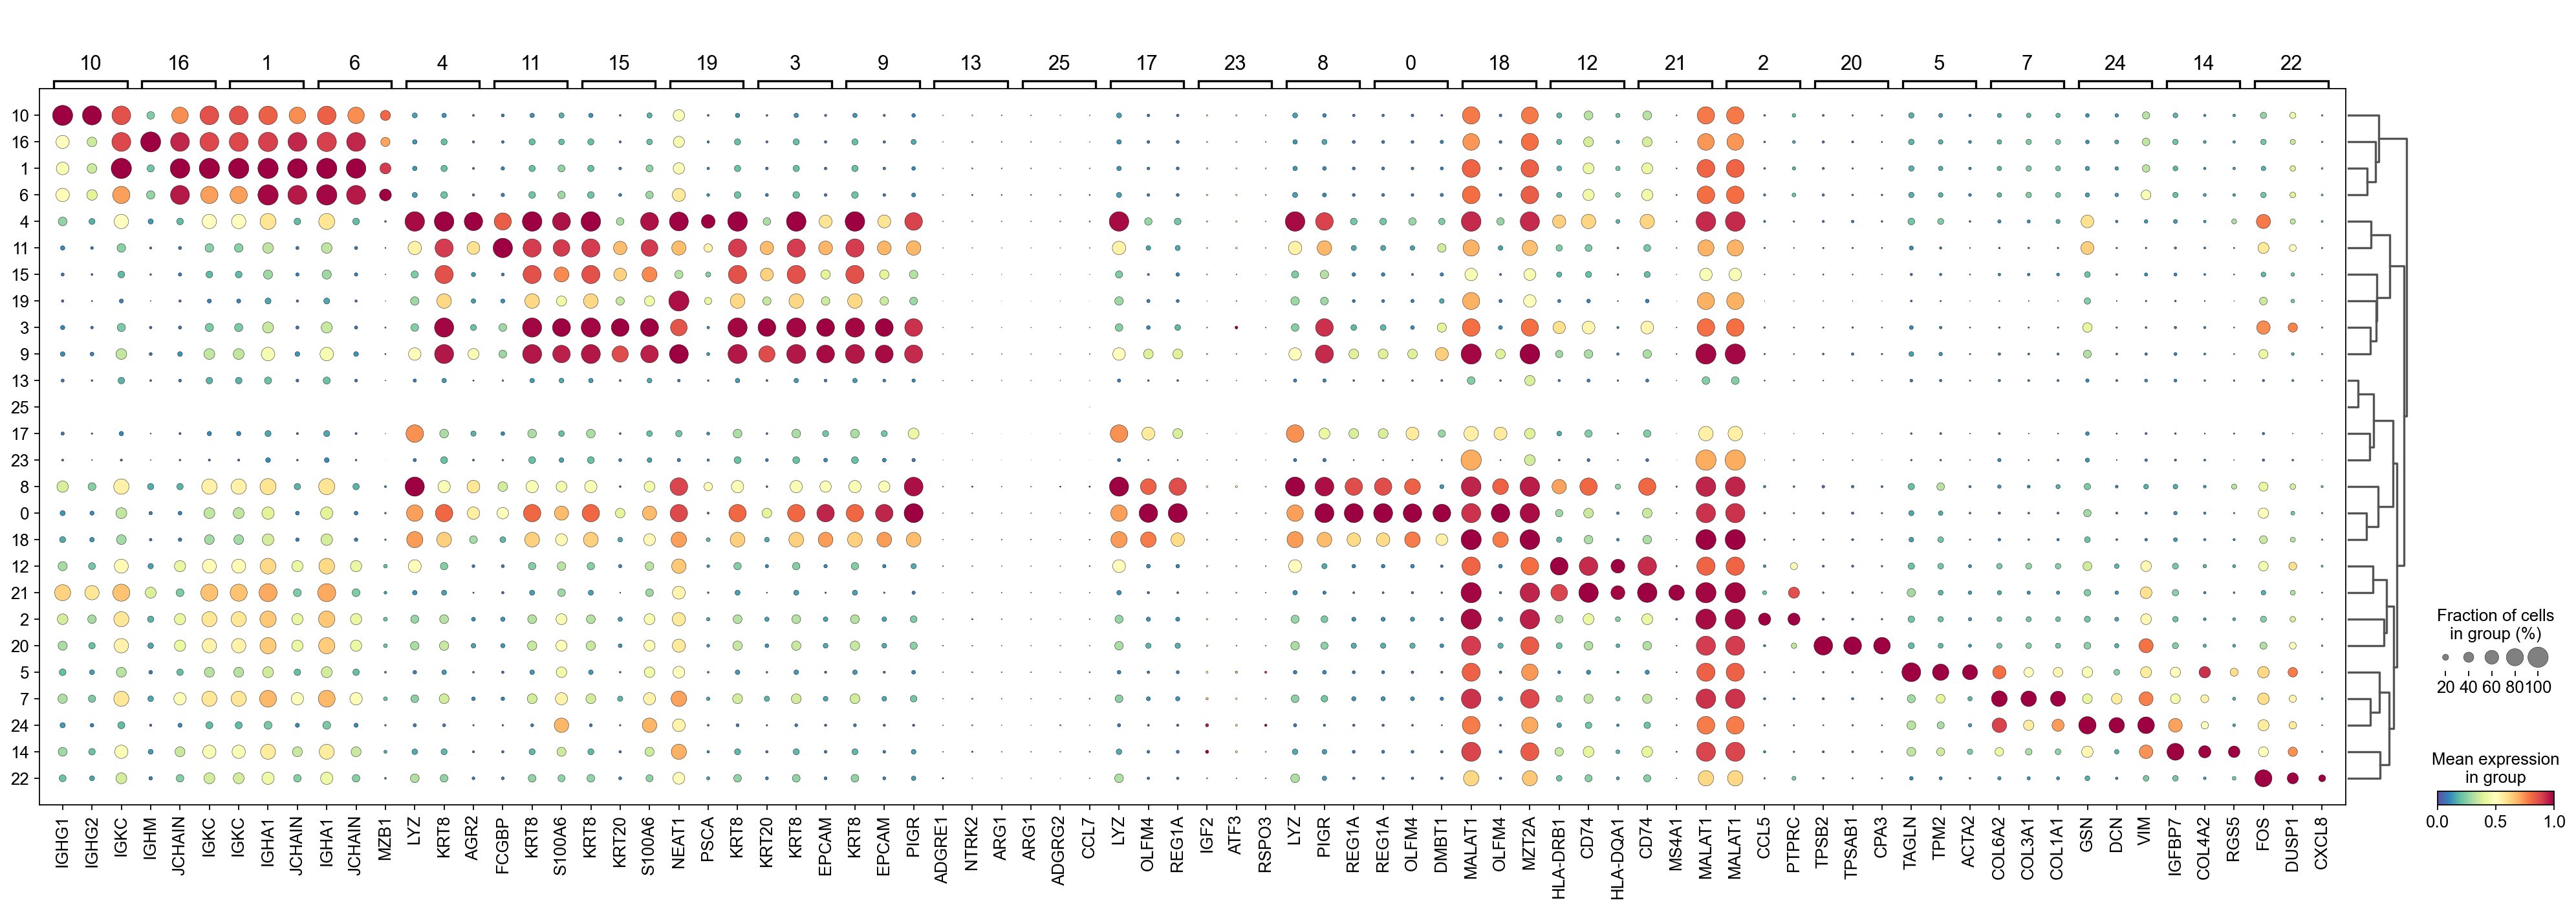

In [78]:
import scanpy as sc
sc.tl.dendrogram(query_adata,'leiden',use_rep='X_scVI')
sc.tl.rank_genes_groups(query_adata, 'leiden', use_rep='X_scVI',
                        method='t-test',use_raw=False,key_added='leiden_ttest')
sc.pl.rank_genes_groups_dotplot(query_adata,groupby='leiden',
                                cmap='Spectral_r',key='leiden_ttest',
                                standard_scale='var',n_genes=3)

In [194]:
marker_dict=ov.single.get_celltype_marker(query_adata,clustertype='leiden',rank=False,
                                  key='leiden_ttest',method='t-test',
                                  scores_type='logfoldchanges',foldchange=1.5,
                                  topgenenumber=10)
query_adata.uns['marker_dict']=marker_dict

...get cell type marker
ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:01)


In [195]:
adata.uns['marker_dict']=marker_dict

In [82]:
import gptbioinsightor as gbi 

### 设置大语言模型的API KEY
import os
os.environ['API_KEY'] = "sk-f03e62ed77fc4ce38682e3b6a887064c"

# 设置数据的背景信息
background = f"Cells from stomatch human" 

# 确保adata已经进行了差异基因分析，例如: sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")
# 我们使用Aliyun 的 qwen2-72b-instruct 进行演示, 但你也可以使用 openai gpt-4o
res = gbi.get_celltype(query_adata.uns['marker_dict'], background=background, 
                    out="result/celltype_info.md", 
                    topnumber=15,provider="aliyun", model="qwen-max")
query_adata.obs['celltype_gbi']=query_adata.obs['leiden'].map(res)


<AxesSubplot: title={'center': 'celltype_gbi'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>

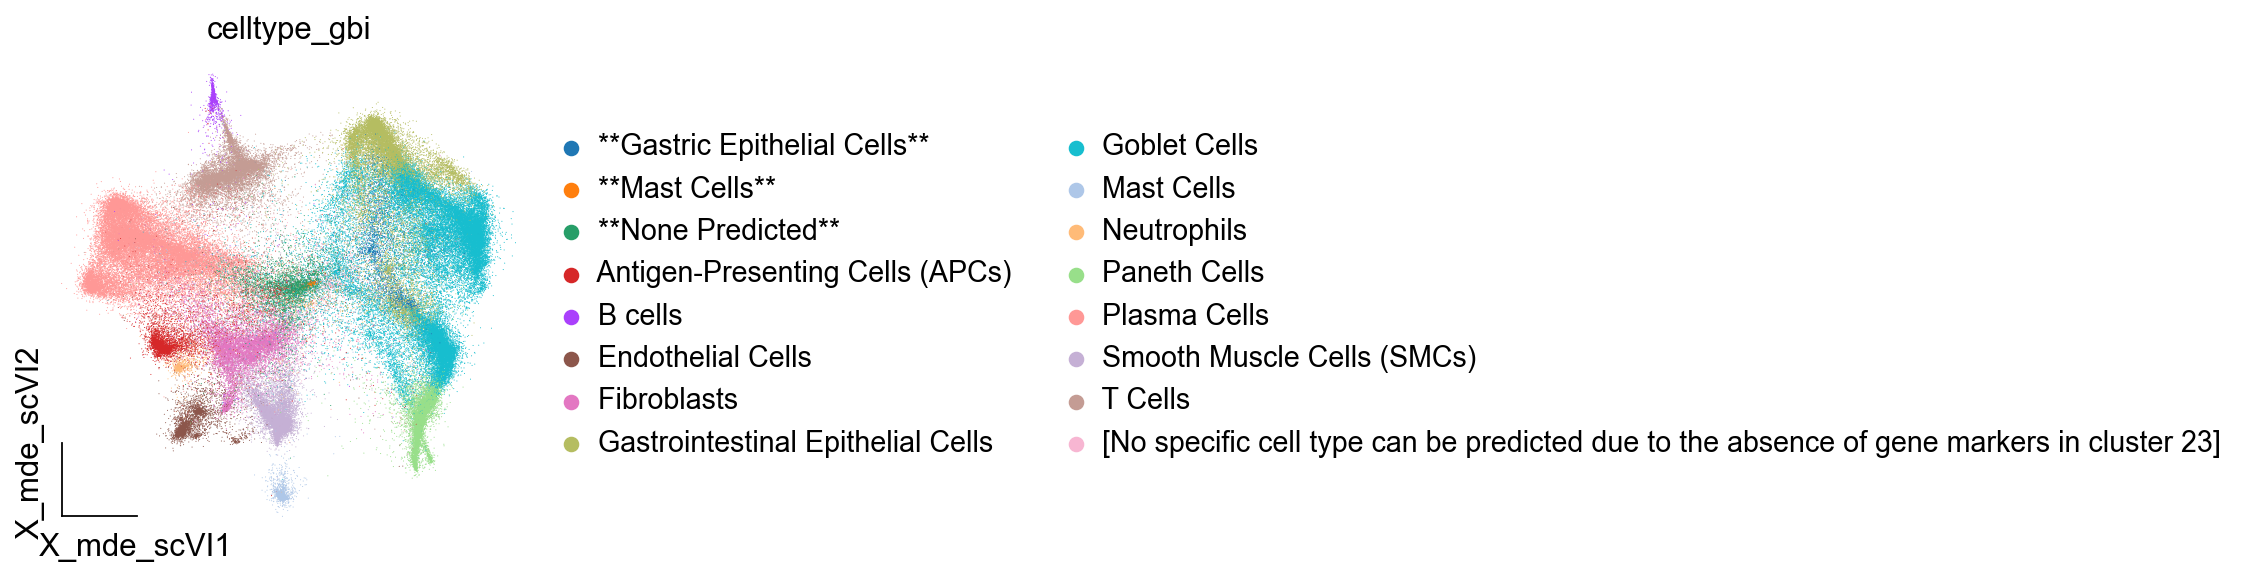

In [83]:
ov.utils.embedding(query_adata,
                basis='X_mde_scVI',frameon='small',
                color=['celltype_gbi'],show=False)

In [85]:
#query_adata.uns['marker_dict']=all_markers
query_adata.obs['best_clusters']=query_adata.obs['leiden']

In [144]:
import os
os.environ['AGI_API_KEY'] = 'sk-FF3MmMGS836Ca29A00A6T3BLBKFJ3BC8ebf196c444659442'  # Replace with your actual API key


In [89]:
!ping c-z0-api-01.hash070.com

PING gb71f07.cdn.miocdn.top (46.232.54.205) 56(84) bytes of data.
64 bytes from 46.232.54.205 (46.232.54.205): icmp_seq=1 ttl=50 time=47.1 ms
64 bytes from 46.232.54.205 (46.232.54.205): icmp_seq=2 ttl=50 time=45.1 ms
64 bytes from 46.232.54.205 (46.232.54.205): icmp_seq=3 ttl=50 time=43.3 ms
^C

--- gb71f07.cdn.miocdn.top ping statistics ---
3 packets transmitted, 3 received, 0% packet loss, time 2003ms
rtt min/avg/max/mdev = 43.259/45.157/47.114/1.574 ms


In [101]:
adata=query_adata

In [ ]:
adata.uns['marker_dict']

In [ ]:
def celltype_anno_gpt4celltype(adata,model='gpt-4o',base_url="https://c-z0-api-01.hash070.com/v1",gpt_num=5):
    result_gpt_dict={}
    from tqdm import tqdm
    for t in tqdm(range(gpt_num)):
        result_gpt = ov.single.gptcelltype(adata.uns['marker_dict'],
                                       tissuename='stomach', speciename='human',
                              model=model,base_url=base_url,
                              topgenenumber=10)
        result_gpt_dict[t]=result_gpt
        adata.obs[f'gpt_celltype_{t}'] = adata.obs['best_clusters'].map(result_gpt).astype('category')
celltype_anno_gpt4celltype(query_adata)

In [116]:
model='gpt-4o'
base_url='https://c-z0-api-01.hash070.com/v1'
gpt_num=5
import os
os.environ['AGI_API_KEY'] = 'sk-FF3MmMGS836Ca29A00A6T3BLBKFJ3BC8ebf196c444659442'  # Replace with your actual API key
#os.environ['AGI_API_KEY'] = 'sk-f03e62ed77fc4ce38682e3b6a887064c'  # Replace with your actual API key

In [139]:
model='qwen-max'
base_url='https://dashscope.aliyuncs.com/compatible-mode/v1'
gpt_num=5
import os
#os.environ['AGI_API_KEY'] = 'sk-FF3MmMGS836Ca29A00A6T3BLBKFJ3BC8ebf196c444659442'  # Replace with your actual API key
os.environ['AGI_API_KEY'] = 'sk-f03e62ed77fc4ce38682e3b6a887064c'  # Replace with your actual API key

In [140]:
gpt_num=5
cluster_celltypes={}
adata=query_adata
adata.obs['best_clusters']=adata.obs['best_clusters'].astype('category')
for ct in adata.obs['best_clusters'].cat.categories:
    ct1=adata.obs.loc[adata.obs['best_clusters']==ct,'celltype_gbi'].value_counts().index[0]
    ct2=adata.obs.loc[adata.obs['best_clusters']==ct,'Prediction'].value_counts().index[0]
    ct_li=[]
    #for num in range(gpt_num):
    #    ct_li.append(adata.obs.loc[adata.obs['best_clusters']==ct,f'gpt_celltype_{num}'].value_counts().index[0])

    cluster_celltypes[ct]=[ct1,ct2]+ct_li

cluster_markers = adata.uns['marker_dict']

# 调用函数并打印结果
result = get_cluster_celltype(cluster_celltypes, cluster_markers, 
                              species='human', organization='stomach',
                             model=model,base_url=base_url)
#adata.obs['best_celltype'] = adata.obs['best_clusters'].map(result).astype('category')
#adata.obs['best_celltype']=[i.capitalize() for i in adata.obs['best_celltype'].tolist()]

100%|██████████| 26/26 [00:18<00:00,  1.39it/s]


<AxesSubplot: title={'center': 'best_celltype'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>

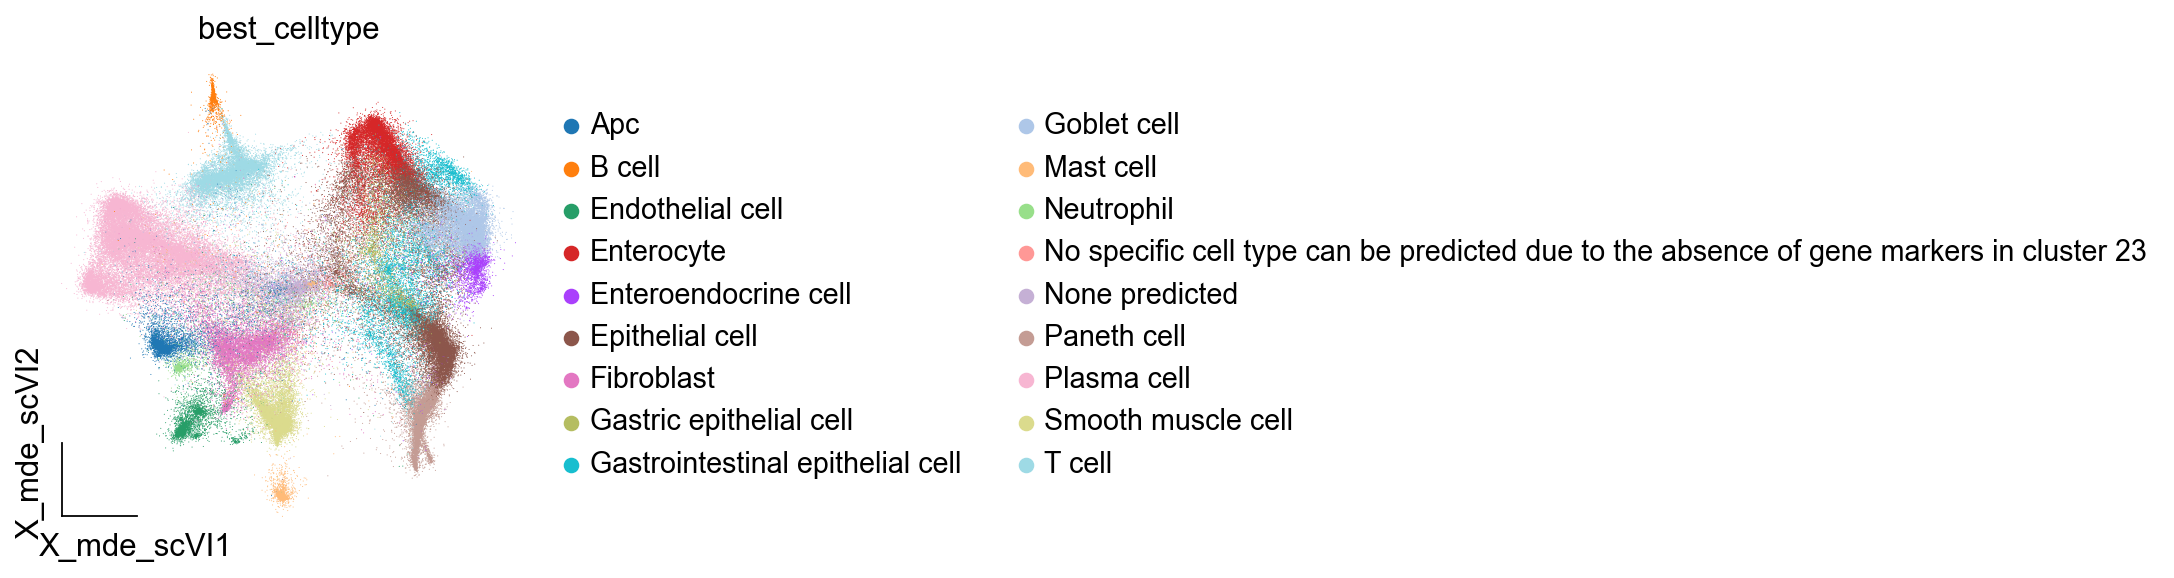

In [132]:
ov.utils.embedding(query_adata,
                basis='X_mde_scVI',frameon='small',
                color=['best_celltype'],show=False)

In [136]:
query_adata.obs['best_celltype']=query_adata.obs['best_celltype'].astype(str)
query_adata.obs.loc[query_adata.obs['best_celltype']=='No specific cell type can be predicted due to the absence of gene markers in cluster 23',
'best_celltype']='Unknown'
query_adata.obs.loc[query_adata.obs['best_celltype']=='None predicted',
'best_celltype']='Unknown'



<AxesSubplot: title={'center': 'best_celltype'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>

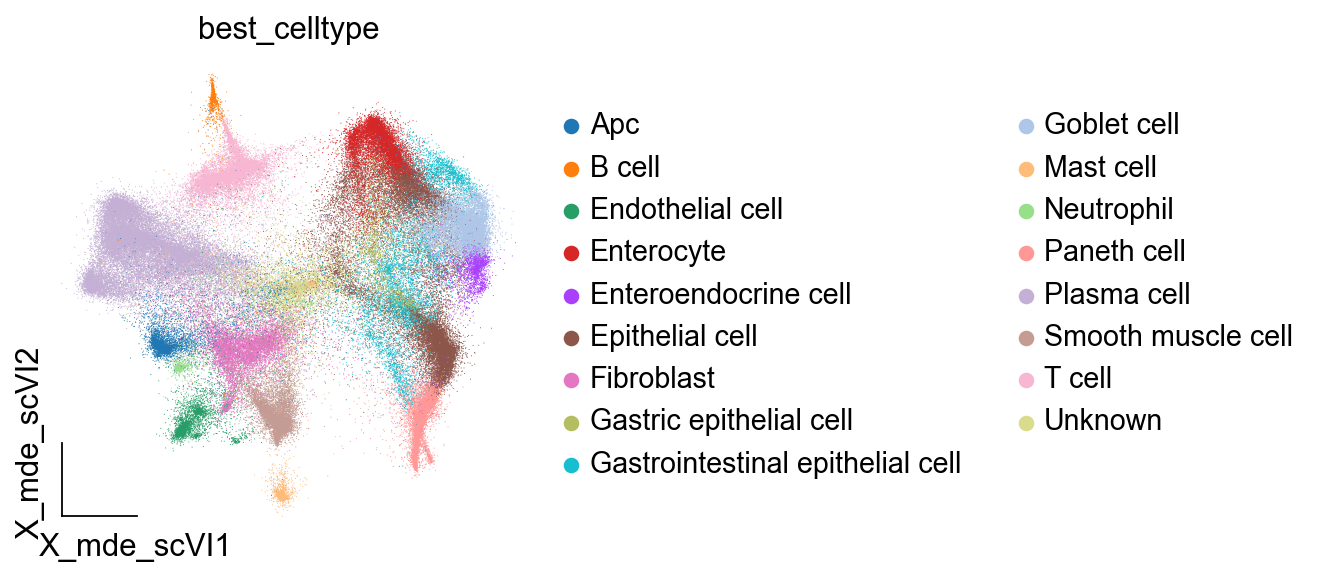

In [137]:
ov.utils.embedding(query_adata,
                basis='X_mde_scVI',frameon='small',
                color=['best_celltype'],show=False)

In [138]:
query_adata.write(f'data/{dataset_id}_tosica_anno.h5ad')

In [130]:

def get_cluster_celltype(cluster_celltypes, cluster_markers, species, organization,
                        model,base_url):
    from openai import OpenAI
    import os
    import numpy as np
    import pandas as pd
    import requests as requests
    if base_url is None:
        if provider == 'openai':
            base_url = "https://api.openai.com/v1"
        elif provider == 'kimi':
            base_url = "https://api.moonshot.cn/v1"
        elif provider == 'qwen':
            base_url = "https://dashscope.aliyuncs.com/compatible-mode/v1"
    QWEN_API_KEY = os.getenv("AGI_API_KEY")
    
    
    # 在这里配置您在本站的API_KEY
    api_key = QWEN_API_KEY
    
    headers = {
        "Authorization": 'Bearer ' + api_key,
    }
    cluster_celltype = {}
    from tqdm import tqdm
    for cluster_id, celltypes in tqdm(cluster_celltypes.items()):
        markers = cluster_markers.get(cluster_id, [])
        question = (
                    f"Given the species: {species} and organization: {organization}, "
                    f"determine the most suitable cell type for cluster {cluster_id}. "
                    f"The possible cell types are: {', '.join(celltypes)}. "
                    f"The gene markers for this cluster are: {', '.join(markers)}. "
                    f"Which cell type best represents this cluster? "
                    f"Only provide the cell type name. Do not show numbers before the name. Some can be a mixture of multiple cell types."
                    f"Do not provide the plural form of celltype."
                )
        #print(question)
        
        params = {
            "messages": [
        
                {
                    "role": 'user',
                    "content": question
                }
            ],
            # 如果需要切换模型，在这里修改
            "model": model
        }
        response = requests.post(
            f"{base_url}/chat/completions",
            headers=headers,
            json=params,
            stream=False
        )
        res = response.json()
        answer = res['choices'][0]['message']['content'].split('\n')
        # 将回答加入结果字典
        cluster_celltype[cluster_id] = answer[0].lower()
    
    return cluster_celltype

In [204]:
import requests
import os
import numpy as np
import pandas as pd

def gpt4celltype(input_data, tissuename=None, speciename='human',
                provider='qwen', model='qwen-plus', topgenenumber=10,
                base_url=None):
    """
    Annotation of cell types using AGI model.

    Arguments:
        input: dict, input dictionary with clusters as keys and gene markers as values.
        tissuename: str, tissue name.
        provider: str, provider of the model. Default: 'qwen', you can select from ['openai','kimi','qwen'] now.

    """
    input=input_data.copy()
    input_data=input
    del_k=[]
    for k in input_data:
        if len(input_data[k])==0:
            del_k.append(k)
    for k in del_k:
        del input[k]
    
    if base_url is None:
        if provider == 'openai':
            base_url = "https://api.openai.com/v1"
        elif provider == 'kimi':
            base_url = "https://api.moonshot.cn/v1"
        elif provider == 'qwen':
            base_url = "https://dashscope.aliyuncs.com/compatible-mode/v1"

    QWEN_API_KEY = os.getenv("AGI_API_KEY")
    if QWEN_API_KEY == "":
        print("Note: AGI API key not found: returning the prompt itself.")
        API_flag = False
    else:
        API_flag = True

    if isinstance(input, dict):
        input = {k: 'unknown' if not v else ','.join(v[:topgenenumber]) for k, v in input.items()}
    elif isinstance(input, pd.DataFrame):
        # Filter genes with positive log fold change and group by cluster, selecting top genes
        input = input[input['logfoldchanges'] > 0]
        input = input.groupby('cluster')['names'].apply(lambda x: ','.join(x.iloc[:topgenenumber]))
    else:
        raise ValueError("Input must be either a dictionary of lists or a pandas DataFrame.")

    
    if not API_flag:
        message = f'Identify cell types of {tissuename} cells in {speciename} using the following markers separately for each row. Only provide the cell type name. Do not show numbers before the name. Some can be a mixture of multiple cell types.\n' + '\n'.join([f'{k}: {v}' for k, v in input.items()])
        return message
    else:
        print("Note: AGI API key found: returning the cell type annotations.")
        
        headers = {
            "Authorization": f"Bearer {QWEN_API_KEY}",
        }
        
        cutnum = int(np.ceil(len(input) / 30))
        if cutnum > 1:
            cid = np.digitize(range(1, len(input) + 1), bins=np.linspace(1, len(input), cutnum + 1))
        else:
            cid = np.ones(len(input), dtype=int)
        
        allres = {}
        from tqdm import tqdm
        for i in tqdm(range(1, cutnum + 1)):
            id_list = [j for j, x in enumerate(cid) if x == i]
            flag = False
            while not flag:
                messages = [{"role": "user", 
                             "content": f'Identify cell types of {tissuename} cells using the following markers separately for each row. Only provide the cell type name. Do not show numbers before the name. Some can be a mixture of multiple cell types.\n' + '\n'.join([input[list(input.keys())[j]] for j in id_list if input[list(input.keys())[j]] != 'unknown'])}]
                
                params = {
                    "model": model,
                    "messages": messages
                }
                
                
                response = requests.post(
                    f"{base_url}/chat/completions",
                    headers=headers,
                    json=params,
                    stream=False
                )
                
                res = response.json()
                
                if 'choices' in res and len(res['choices']) > 0:
                    res_content = res['choices'][0]['message']['content'].split('\n')
                    #print(res_content)
                    if len(res_content) == len(id_list):
                        flag = True
                        for idx, cell_type in zip(id_list, res_content):
                            key = list(input.keys())[idx]
                            allres[key] = 'unknown' if input[key] == 'unknown' else cell_type.strip(',')
        
        print('Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.')
        for k in del_k:
            allres[k]='Unknown'
        return allres

In [205]:
model='gpt-4o'
base_url='https://c-z0-api-01.hash070.com/v1'
gpt_num=5
import os
os.environ['AGI_API_KEY'] = 'sk-FF3MmMGS836Ca29A00A6T3BLBKFJ3BC8ebf196c444659442'  # Replace with your actual API key
#os.environ['AGI_API_KEY'] = 'sk-f03e62ed77fc4ce38682e3b6a887064c'  # Replace with your actual API key

In [206]:
gpt4celltype(adata.uns['marker_dict'],
                             tissuename='stomach', speciename='human',
                              model=model,base_url=base_url,
                              topgenenumber=10)

Note: AGI API key found: returning the cell type annotations.


100%|██████████| 1/1 [00:04<00:00,  4.57s/it]

Note: It is always recommended to check the results returned by GPT-4 in case of AI hallucination, before going to downstream analysis.


{'0': 'Enteroendocrine cell  ',
 '1': 'Plasma cell  ',
 '10': 'Plasma cell  ',
 '11': 'Enterocyte  ',
 '12': 'Macrophage  ',
 '14': 'Endothelial cell  ',
 '15': 'Epithelial cell  ',
 '16': 'Plasma cell  ',
 '17': 'Paneth cell  ',
 '18': 'Tuft cell  ',
 '19': 'Epithelial cell  ',
 '2': 'T cell  ',
 '20': 'Mast cell  ',
 '21': 'B cell  ',
 '22': 'Neutrophil  ',
 '24': 'Fibroblast  ',
 '3': 'Enterocyte  ',
 '4': 'Enteroendocrine cell  ',
 '5': 'Smooth muscle cell  ',
 '6': 'Plasma cell  ',
 '7': 'Fibroblast  ',
 '8': 'Goblet cell  ',
 '9': 'Enterocyte',
 '13': 'Unknown',
 '23': 'Unknown',
 '25': 'Unknown'}